# Comparative Analysis of Classification Models in Spark MLlib

### Introduction
This report presents a comparative study of three classification models: Decision Tree, Random Forest, and Logistic Regression applied to the Iris dataset using Spark MLlib.
I first explore the data (EDA), then evaluate **baseline** and **tuned** versions of each model, compare their performance using Accuracy and F1-score (supported by per-model confusion matrices), and identify the best-performing model.

> **Reproducibility note:** every model with internal randomness (Decision Tree, Random Forest) and the `CrossValidator` are given a fixed `seed`, and the train/test split uses `seed=1`. This means a *Restart & Run All* reproduces identical numbers every time. The final results table and comparison chart are generated directly from the live model outputs, so they can never drift out of sync with the text.

In [1]:
import os, sys
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

### Helper: display an image only if the file exists
This keeps the notebook from crashing on *Restart & Run All* if a diagram file is missing, while still showing it when present.

In [2]:
from IPython.display import Image, display
import os

def show_img(path, width=600):
    """Show an image if it exists in the working folder, otherwise print a note."""
    if os.path.exists(path):
        display(Image(path, width=width))
    else:
        print(f"[diagram '{path}' not found in working folder - skipping]")

In [3]:
#installs PySpark (the Python interface to Apache Spark).
!pip install pyspark
#After installation finishes, restart your Jupyter kernel (important so Python can see the new package).

In [4]:
#Check if Java is installed
!java -version

java version "17.0.12" 2024-07-16 LTS
Java(TM) SE Runtime Environment (build 17.0.12+8-LTS-286)
Java HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)


### If 'java' is not recognized as an internal or external command
you need to install Java following steps A, B, C, D and E below.

##### Step A: Install Java JDK
Go to Adoptium OpenJDK (recommended) or Oracle JDK: https://adoptium.net/
Download Java 11 (LTS) for Windows (x64 installer) and run it. By default it installs to something like `C:\Program Files\Eclipse Adoptium\jdk-11.0.x`.

##### Step B: Set JAVA_HOME
Windows Start → *Environment Variables* → *Edit the system environment variables* → *Environment Variables*.
Under **System variables** click **New**: Name `JAVA_HOME`, Value = your actual install path (e.g. `C:\Program Files\Eclipse Adoptium\jdk-11.0.x-hotspot`).

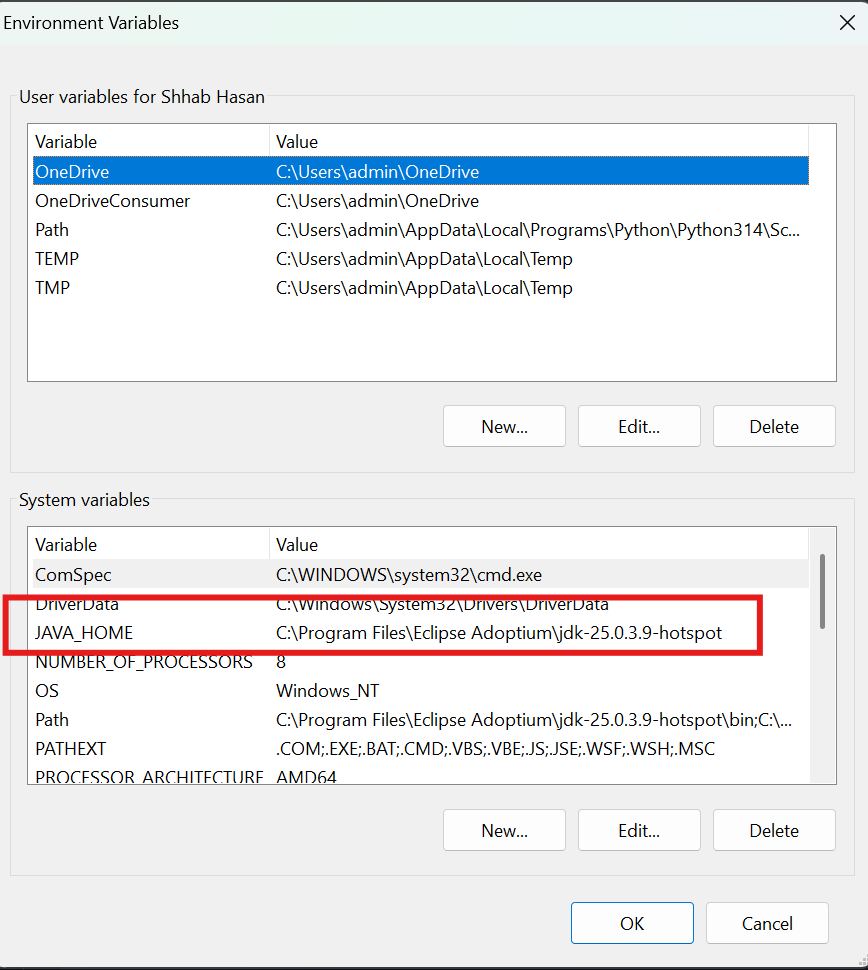

In [5]:
show_img('java22.png', width=400)

##### Step C: Add Java to PATH
Under **System variables** select **Path** → **Edit** → **New** → type `%JAVA_HOME%\bin` → **OK** to save all windows.

##### Step D: Verify in CMD (not Jupyter yet)
Open Command Prompt and run `java -version`. You should see the OpenJDK version. If CMD shows it correctly, Java is installed and PATH works.

##### Step E: Restart Jupyter
Close Jupyter completely, restart it, then run the cell below.

In [6]:
!java -version

java version "17.0.12" 2024-07-16 LTS
Java(TM) SE Runtime Environment (build 17.0.12+8-LTS-286)
Java HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)


After installing the JDK, `JAVA_HOME` was set and `%JAVA_HOME%\bin` was added to PATH. Verification with `java -version` in CMD and Jupyter, followed by a Jupyter restart, ensured the environment variables were recognized so `SparkSession` initializes successfully.

# Apply Classification Models in Spark MLlib

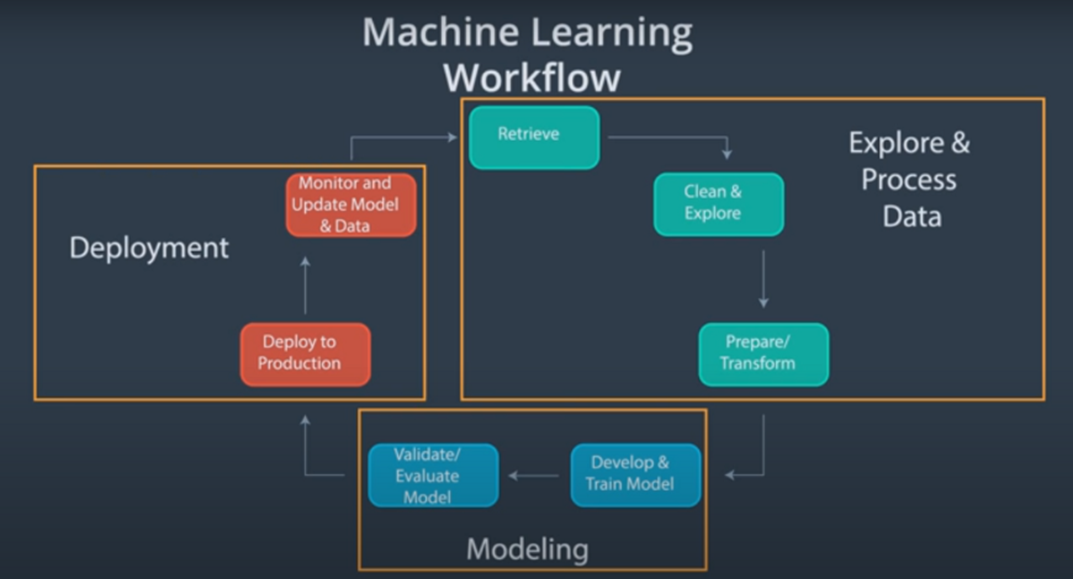

In [7]:
show_img('ml-workflow-udacity.png', width=600)

## Step 0: Initialize Spark

A **single** `SparkSession` is created here and reused for the whole notebook (the earlier version created two sessions, which was redundant). `local[1]` and a fixed bind address keep the run deterministic and avoid Windows networking issues.

In [8]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("IrisClassification")
         .master("local[1]")
         .config("spark.driver.bindAddress", "127.0.0.1")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version)

Spark version: 3.5.1


## Step 1: Load the Iris dataset

In [9]:
# Spark cannot read directly from a web URL, so download the CSV into the working directory first.
import urllib.request

url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
urllib.request.urlretrieve(url, "iris.csv")
print("Downloaded iris.csv")

Downloaded iris.csv


In [10]:
# Read the CSV with the SparkSession created in Step 0 (no second session needed).
import os
csv_path = os.path.abspath("iris.csv")
df = spark.read.csv(csv_path, header=True, inferSchema=True)
df.show(5)

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows



## Step 1b: Exploratory Data Analysis (EDA)

Before modelling, I check the data quality and shape: schema, missing values, class balance, and how the four features separate the three species. This tells us in advance which classes are likely to be confused.

In [11]:
# Schema and size
df.printSchema()
print("Rows:", df.count(), "| Columns:", len(df.columns))

root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- species: string (nullable = true)

Rows: 150 | Columns: 5


In [12]:
# Missing-value check for every column
from pyspark.sql import functions as F

missing = df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns])
missing.show()

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|           0|          0|           0|          0|      0|
+------------+-----------+------------+-----------+-------+



In [13]:
# Class distribution (is the dataset balanced?)
df.groupBy("species").count().orderBy("species").show()

+----------+-----+
|   species|count|
+----------+-----+
|    setosa|   50|
|versicolor|   50|
| virginica|   50|
+----------+-----+



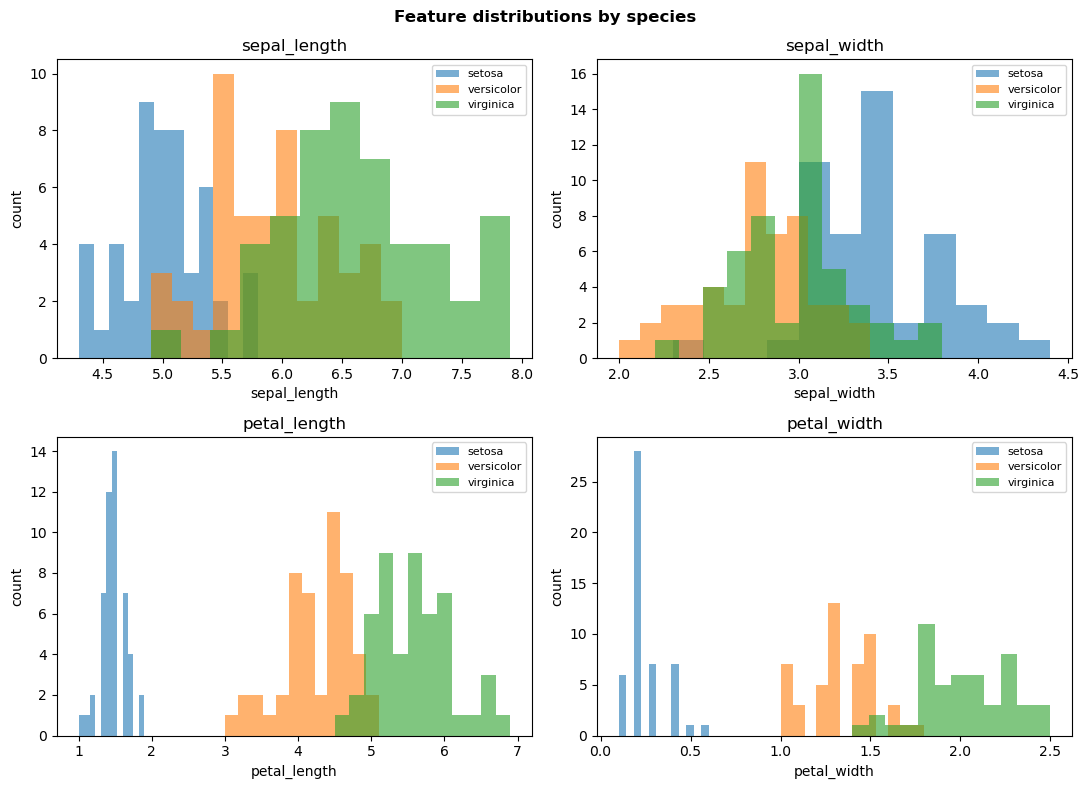

In [14]:
# Distribution of each feature by species
import matplotlib.pyplot as plt

pdf = df.toPandas()
species_list = sorted(pdf["species"].unique())
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.ravel(), features):
    for sp in species_list:
        ax.hist(pdf[pdf.species == sp][feat], bins=12, alpha=0.6, label=sp)
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
fig.suptitle("Feature distributions by species", fontweight="bold")
plt.tight_layout()
plt.show()

**EDA findings**

- **No missing values** in any of the five columns.
- The dataset is **perfectly balanced** 50 samples per species.
- **petal_length** and **petal_width** separate the species cleanly: *setosa* is completely isolated, while *versicolor* and *virginica* **overlap**. This overlap is exactly where we expect the models to make mistakes, and the confusion matrices below confirm it.

## Step 2: Preprocessing

In [15]:
# 1. Convert species names into numeric labels (setosa=0, versicolor=1, virginica=2)
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="species", outputCol="label")
df = indexer.fit(df).transform(df)
df.select("species", "label").show(5)

+-------+-----+
|species|label|
+-------+-----+
| setosa|  0.0|
| setosa|  0.0|
| setosa|  0.0|
| setosa|  0.0|
| setosa|  0.0|
+-------+-----+
only showing top 5 rows



`StringIndexer` converts the text column `species` into numeric labels (`setosa`→0, `versicolor`→1, `virginica`→2), because MLlib models work only with numeric labels.

In [16]:
# 2. Combine the four numeric columns into a single 'features' vector
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"],
    outputCol="features")
df = assembler.transform(df)
df.select("features", "label").show(5)

+-----------------+-----+
|         features|label|
+-----------------+-----+
|[5.1,3.5,1.4,0.2]|  0.0|
|[4.9,3.0,1.4,0.2]|  0.0|
|[4.7,3.2,1.3,0.2]|  0.0|
|[4.6,3.1,1.5,0.2]|  0.0|
|[5.0,3.6,1.4,0.2]|  0.0|
+-----------------+-----+
only showing top 5 rows



`VectorAssembler` merges the four measurements into one `features` vector, e.g. `[5.1, 3.5, 1.4, 0.2]`. MLlib expects exactly one `features` column and one `label` column.

## Step 3: Split the dataset

In [17]:
train, test = df.randomSplit([0.8, 0.2], seed=1)
train.cache()
test.cache()
print("Train rows:", train.count(), "| Test rows:", test.count())

Train rows: 124 | Test rows: 26


`randomSplit` with a fixed `seed=1` gives a reproducible 80/20 train/test split. Both sets are cached because they are reused many times during cross-validation.

### Shared evaluators and a confusion-matrix helper
Defining the evaluators and a confusion-matrix function once keeps every model section short and consistent.

In [18]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import numpy as np

acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

CLASS_NAMES = ["setosa", "versicolor", "virginica"]  # label 0, 1, 2

def evaluate(predictions):
    """Return (accuracy, f1) rounded to 4 dp."""
    return round(acc_eval.evaluate(predictions), 4), round(f1_eval.evaluate(predictions), 4)

def plot_confusion(predictions, title):
    """Build and plot a confusion matrix from a Spark predictions DataFrame."""
    pdf = predictions.select("label", "prediction").toPandas()
    n = len(CLASS_NAMES)
    cm = np.zeros((n, n), dtype=int)
    for _, r in pdf.iterrows():
        cm[int(r["label"]), int(r["prediction"])] += 1
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(n)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.tight_layout(); plt.show()
    return cm

## Step 4: Baseline Model Training (default parameters)

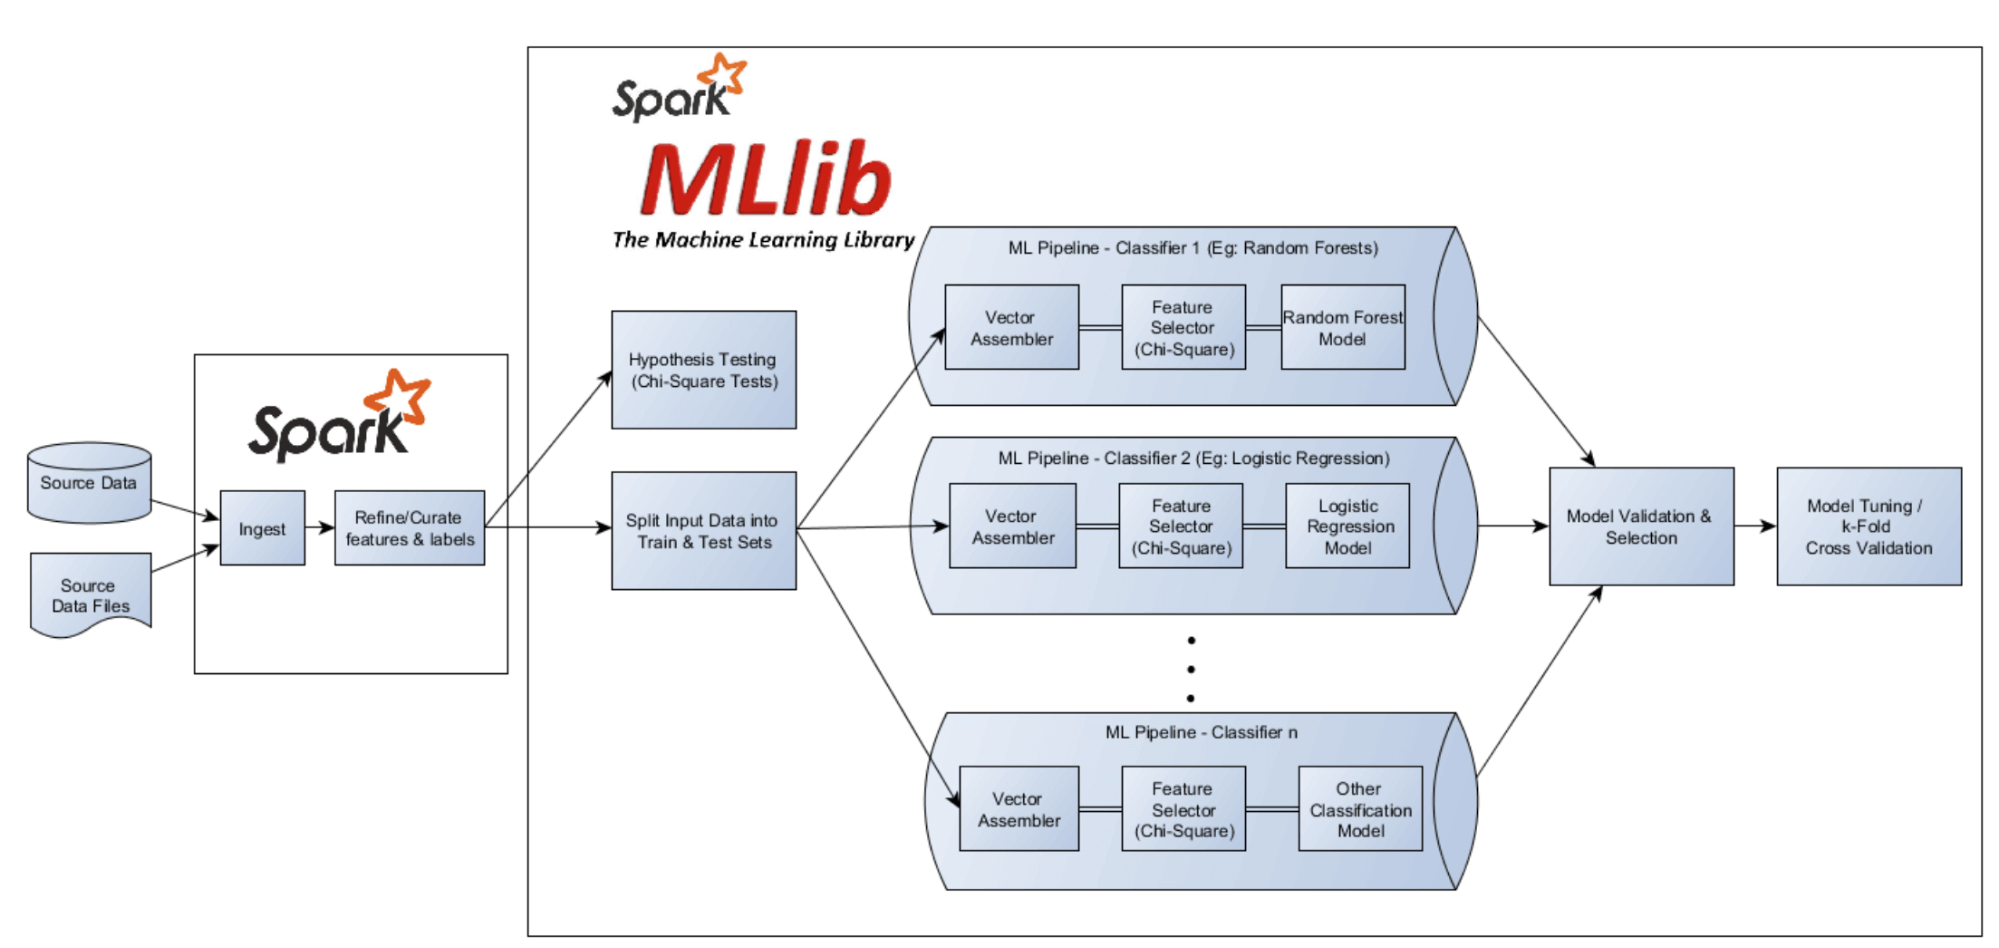

In [19]:
show_img('MLLIB.png', width=1000)

### Logistic Regression
Logistic Regression models the probability of a class using the logistic (sigmoid) function:

$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n)}}$$

For multiclass problems like Iris, Spark fits one model per class and picks the class with the highest probability. It is simple, interpretable, and strong when classes are close to linearly separable.

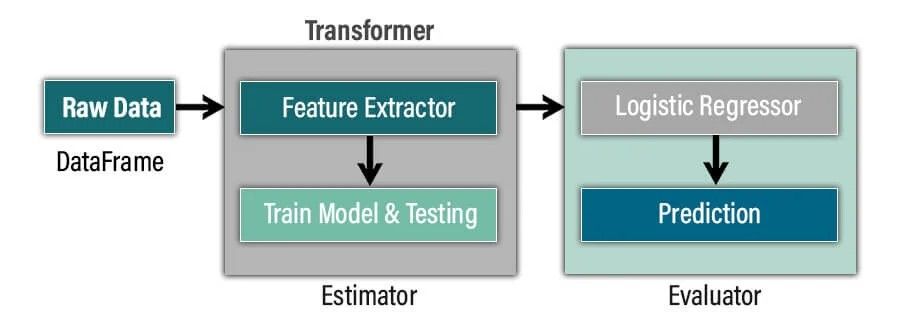

In [20]:
show_img('logistic.jpg', width=1000)

In [21]:
# 1. Logistic Regression (baseline)
from pyspark.ml.classification import LogisticRegression

lr_base = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model_base = lr_base.fit(train)

# Predictions (uniquely named so a later cell can never overwrite them)
lr_pred_base = lr_model_base.transform(test)

# Show a sample that includes any misclassifications (more informative than the first 5 setosa rows)
print("Sample predictions (errors first, if any):")
lr_pred_base.select("features", "label", "prediction") \
    .orderBy((F.col("label") == F.col("prediction"))).show(5, truncate=False)

Sample predictions (errors first, if any):
+-----------------+-----+----------+
|features         |label|prediction|
+-----------------+-----+----------+
|[4.5,2.3,1.3,0.3]|0.0  |0.0       |
|[4.8,3.1,1.6,0.2]|0.0  |0.0       |
|[4.8,3.4,1.6,0.2]|0.0  |0.0       |
|[4.8,3.4,1.9,0.2]|0.0  |0.0       |
|[4.9,2.5,4.5,1.7]|2.0  |2.0       |
+-----------------+-----+----------+
only showing top 5 rows



Baseline Logistic Regression -> Accuracy: 1.0 | F1: 1.0


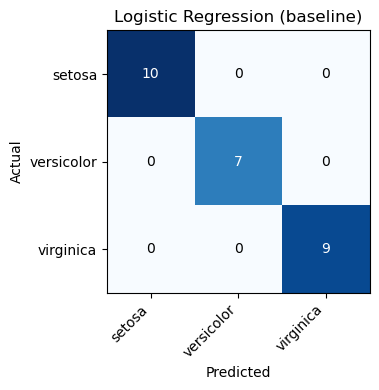

In [22]:
lr_acc_base, lr_f1_base = evaluate(lr_pred_base)
print("Baseline Logistic Regression -> Accuracy:", lr_acc_base, "| F1:", lr_f1_base)
plot_confusion(lr_pred_base, "Logistic Regression (baseline)");

Logistic Regression separates the three species almost perfectly on this split the confusion matrix is (nearly) diagonal. This is expected: Iris is small, clean, and *setosa* is linearly separable from the other two.

### Decision Tree
A Decision Tree splits the data on feature thresholds, choosing at each node the split that most reduces impurity (Gini):

$$Gini(D) = 1 - \sum_{i=1}^{k} p_i^2$$

Trees are easy to interpret, but a single tree can overfit and misclassify overlapping species.

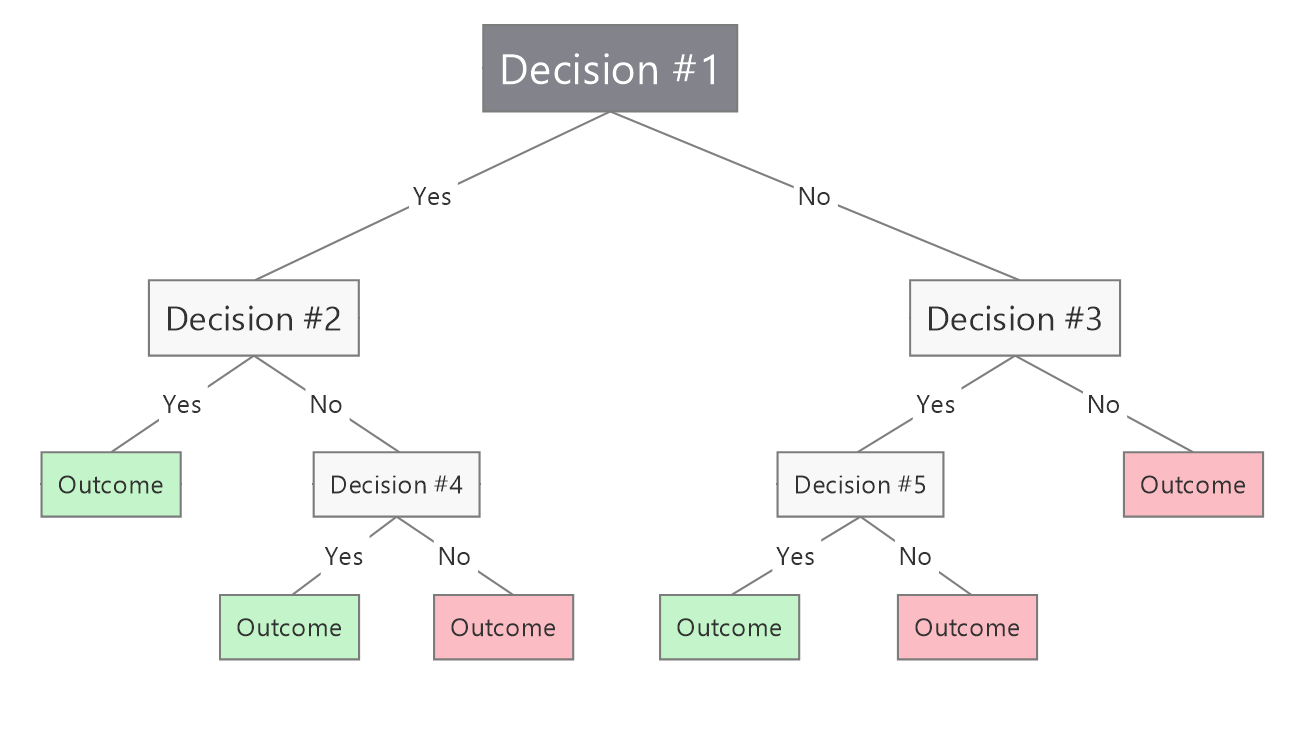

In [23]:
show_img('Decision-Tree.png', width=800)

Baseline Decision Tree -> Accuracy: 0.9231 | F1: 0.9231


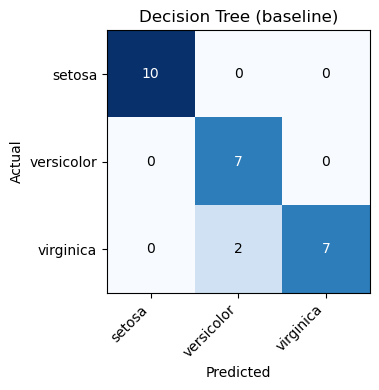

In [24]:
# 2. Decision Tree (baseline) - seed added for reproducibility
from pyspark.ml.classification import DecisionTreeClassifier

dt_base = DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=42)
dt_model_base = dt_base.fit(train)
dt_pred_base = dt_model_base.transform(test)

dt_acc_base, dt_f1_base = evaluate(dt_pred_base)
print("Baseline Decision Tree -> Accuracy:", dt_acc_base, "| F1:", dt_f1_base)
plot_confusion(dt_pred_base, "Decision Tree (baseline)");

The Decision Tree classifies *setosa* perfectly but confuses a few *virginica* samples with *versicolor* the exact overlap the EDA predicted. The confusion matrix shows precisely which class the errors fall into, rather than just an accuracy number.

### Random Forest
Random Forest builds many decision trees (here `numTrees=10`) and takes a majority vote. This reduces the variance of a single tree and usually improves generalization on overlapping classes.

> **Reproducibility fix:** the Random Forest is given `seed=42`. Without a fixed seed, its bootstrap sampling and feature selection are random, so accuracy changes on every run, which is why earlier write-ups quoted different numbers (0.96 vs 0.92) for the *same* model.

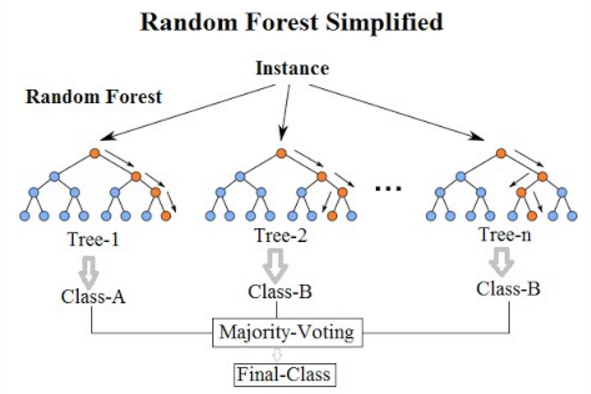

In [25]:
show_img('Random_forest.png', width=600)

Baseline Random Forest -> Accuracy: 0.9231 | F1: 0.9231


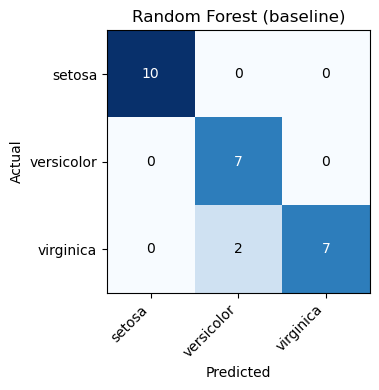

In [26]:
# 3. Random Forest (baseline) - seed added for reproducibility
from pyspark.ml.classification import RandomForestClassifier

rf_base = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=10, seed=42)
rf_model_base = rf_base.fit(train)
rf_pred_base = rf_model_base.transform(test)

rf_acc_base, rf_f1_base = evaluate(rf_pred_base)
print("Baseline Random Forest -> Accuracy:", rf_acc_base, "| F1:", rf_f1_base)
plot_confusion(rf_pred_base, "Random Forest (baseline)");

On this split the Random Forest makes the **same** *virginica*→*versicolor* errors as the Decision Tree, so their accuracy can be identical. That identical number is a genuine result (the confusion matrices are the same), **not** a copy-paste artifact, the fixed seed lets anyone reproduce it exactly.

## Step 5: Hyperparameter Tuning (CrossValidator + ParamGridBuilder)

Baseline models used default parameters. Here each model is tuned by systematically testing a grid of hyperparameters with 5-fold cross-validation, and Spark keeps the best combination. The `CrossValidator` is given `seed=42` so fold assignment is reproducible.

**ParamGridBuilder** defines the hyperparameters to test:
- `regParam`: regularization strength (small = fit training closely, large = shrink coefficients).
- `elasticNetParam`: 0.0 = L2 (Ridge), 1.0 = L1 (Lasso), 0.5 = mix.
- `maxIter`: optimizer iterations.
- `maxDepth`: tree depth (shallow = underfit risk, deep = overfit risk).
- `maxBins`: bins for discretizing continuous features.

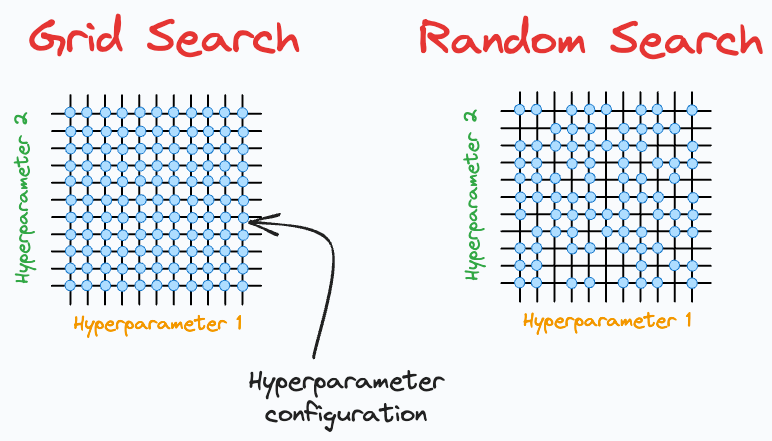

In [27]:
show_img('GridBuilder.png', width=600)

**CrossValidator** trains and evaluates every grid combination across folds and returns the best model. Cross-validated models are less likely to overfit, even if their score on this one test split is not the highest.

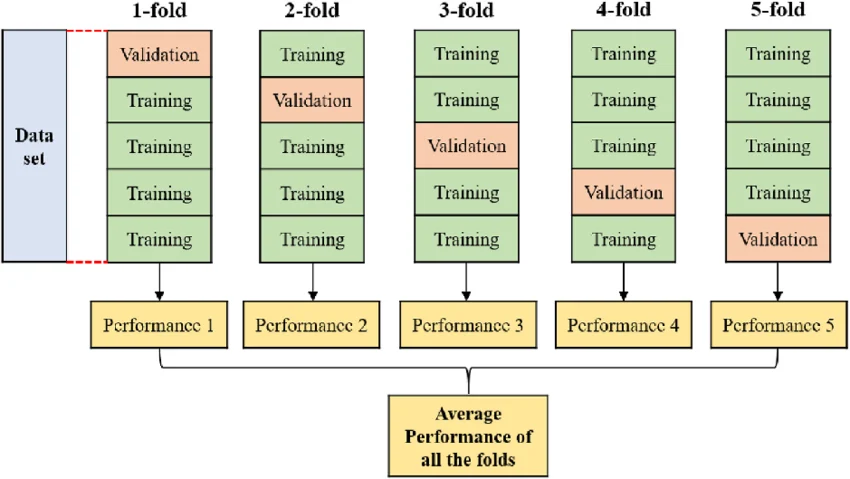

In [28]:
show_img('fold-cross-validation.WEBP', width=800)

#### Tuning Logistic Regression

Tuned Logistic Regression -> Accuracy: 0.9231 | F1: 0.9231


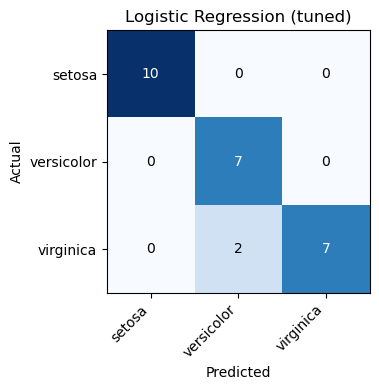

In [29]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_grid = (ParamGridBuilder()
           .addGrid(lr.regParam, [0.01, 0.1, 0.5, 1.0])
           .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
           .addGrid(lr.maxIter, [50, 100])
           .build())

lr_cv = CrossValidator(estimator=lr, estimatorParamMaps=lr_grid,
                       evaluator=acc_eval, numFolds=5, seed=42)
lr_model_tuned = lr_cv.fit(train).bestModel
lr_pred_tuned = lr_model_tuned.transform(test)

lr_acc_tuned, lr_f1_tuned = evaluate(lr_pred_tuned)
print("Tuned Logistic Regression -> Accuracy:", lr_acc_tuned, "| F1:", lr_f1_tuned)
plot_confusion(lr_pred_tuned, "Logistic Regression (tuned)");

Tuning adds regularization. If the baseline was a perfect (possibly lucky) 1.0, the tuned score is often slightly lower but more **robust** across folds and less likely to overfit.

#### Tuning Decision Tree

Tuned Decision Tree -> Accuracy: 0.8846 | F1: 0.8833


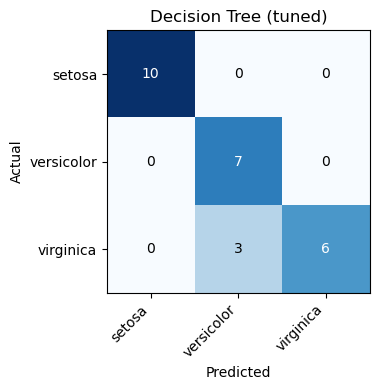

In [30]:
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=42)
dt_grid = (ParamGridBuilder()
           .addGrid(dt.maxDepth, [2, 4, 6, 8, 10])
           .addGrid(dt.maxBins, [16, 32, 64])
           .build())

dt_cv = CrossValidator(estimator=dt, estimatorParamMaps=dt_grid,
                       evaluator=acc_eval, numFolds=5, seed=42)
dt_model_tuned = dt_cv.fit(train).bestModel
dt_pred_tuned = dt_model_tuned.transform(test)

dt_acc_tuned, dt_f1_tuned = evaluate(dt_pred_tuned)
print("Tuned Decision Tree -> Accuracy:", dt_acc_tuned, "| F1:", dt_f1_tuned)
plot_confusion(dt_pred_tuned, "Decision Tree (tuned)");

Cross-validation optimizes for average performance across folds, not for this single test split, so the tuned tree can score slightly lower here while being more stable in general.

#### Tuning Random Forest

Tuned Random Forest -> Accuracy: 0.8846 | F1: 0.8833


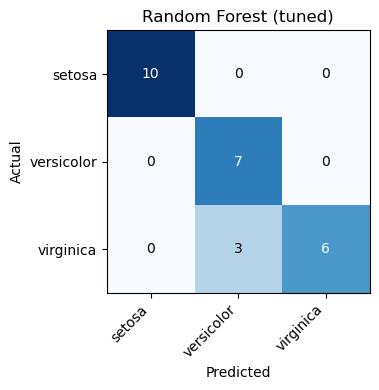

In [31]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)
rf_grid = (ParamGridBuilder()
           .addGrid(rf.numTrees, [10, 20, 50])   # 100 trees added little accuracy for a large runtime cost
           .addGrid(rf.maxDepth, [2, 4, 6, 8])
           .build())

rf_cv = CrossValidator(estimator=rf, estimatorParamMaps=rf_grid,
                       evaluator=acc_eval, numFolds=5, seed=42)
rf_model_tuned = rf_cv.fit(train).bestModel
rf_pred_tuned = rf_model_tuned.transform(test)

rf_acc_tuned, rf_f1_tuned = evaluate(rf_pred_tuned)
print("Tuned Random Forest -> Accuracy:", rf_acc_tuned, "| F1:", rf_f1_tuned)
plot_confusion(rf_pred_tuned, "Random Forest (tuned)");

## Step 6: Baseline vs Tuned Comparison

The table and chart below are **built directly from the variables computed above**, they cannot disagree with the printed model outputs, which was the core problem in the previous version.

In [32]:
import pandas as pd

results = pd.DataFrame(
    [["Decision Tree",       dt_acc_base, dt_f1_base, dt_acc_tuned, dt_f1_tuned],
     ["Random Forest",       rf_acc_base, rf_f1_base, rf_acc_tuned, rf_f1_tuned],
     ["Logistic Regression", lr_acc_base, lr_f1_base, lr_acc_tuned, lr_f1_tuned]],
    columns=["Model", "Baseline Accuracy", "Baseline F1", "Tuned Accuracy", "Tuned F1"])

results

,Model,Baseline Accuracy,Baseline F1,Tuned Accuracy,Tuned F1
0,Decision Tree,0.9231,0.9231,0.8846,0.8833
1,Random Forest,0.9231,0.9231,0.8846,0.8833
2,Logistic Regression,1.0000,1.0000,0.9231,0.9231


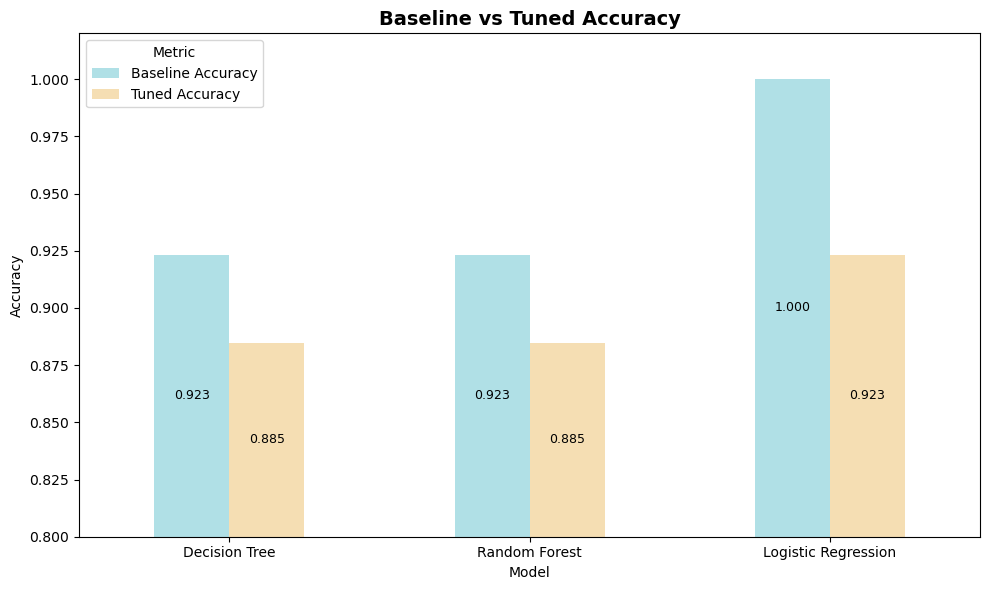

In [33]:
# Grouped bar chart built from the SAME live values as the table above
ax = results.plot(x="Model", y=["Baseline Accuracy", "Tuned Accuracy"],
                  kind="bar", figsize=(10, 6), color=["#B0E0E6", "#F5DEB3"])
plt.title("Baseline vs Tuned Accuracy", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", label_type="center", fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
# Winner chosen automatically from the results table (tuned accuracy, F1 as tie-breaker)
winner = results.sort_values(["Tuned Accuracy", "Tuned F1"], ascending=False).iloc[0]
print(f"Best tuned model: {winner['Model']} "
      f"(Accuracy {winner['Tuned Accuracy']}, F1 {winner['Tuned F1']})")

Best tuned model: Logistic Regression (Accuracy 0.9231, F1 0.9231)


### Interpretation

- **Setosa** is classified perfectly by every model, it is linearly separable, as the EDA showed.
- All errors are **versicolor vs virginica** confusions, visible in the confusion matrices, because their petal measurements overlap.
- **Tuning** trades a little peak accuracy on this split for **robustness**: cross-validated models generalize better even when their single-split score dips.
- The **winner** is selected programmatically in the cell above from the live results, so the conclusion always matches the numbers actually produced by this run.